# Group 8 — People Analytics: Who's a Flight Risk?
### Data Understanding, Cleaning & Exploratory Data Analysis

**Dataset:** IBM HR Analytics Employee Attrition
**Goal:** Understand and clean the raw data, then explore what patterns relate to attrition,
before moving on to clustering and predictive modelling.


## 1. Import libraries

In [67]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("charts", exist_ok=True)
sns.set_style("whitegrid")
%matplotlib inline


## 2. Load raw dataset

In [68]:
df = pd.read_csv("Employee-Attrition.csv")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset loaded: 1470 rows, 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Data Understanding

We look at the raw data before touching anything, so every cleaning decision
later is based on evidence, not guesswork.

### 3.1 Shape

In [69]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Shape: 1470 rows, 35 columns


### 3.2 Data types

In [70]:
df.dtypes


Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

### 3.3 Unique values

In [71]:
df.nunique().sort_values()


Over18                         1
StandardHours                  1
EmployeeCount                  1
Gender                         2
Attrition                      2
PerformanceRating              2
OverTime                       2
MaritalStatus                  3
Department                     3
BusinessTravel                 3
StockOptionLevel               4
EnvironmentSatisfaction        4
JobInvolvement                 4
JobSatisfaction                4
RelationshipSatisfaction       4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

### 3.4 Descriptive statistics

In [72]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


## 4. Data Cleaning

Steps: check for missing values, duplicates, constant columns, ID columns,
outliers, then encode text columns into numbers.

### 4.1 Missing values

In [73]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(f"Columns with missing values: {len(missing)}")
missing


Columns with missing values: 0


Series([], dtype: int64)

### 4.2 Duplicates

In [74]:
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")
df = df.drop_duplicates()


Duplicate rows: 0


### 4.3 Constant columns

A constant column has the exact same value for every employee, so it carries
zero information for prediction or clustering.

In [75]:
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constant columns (same value everywhere): {constant_columns}")


Constant columns (same value everywhere): ['EmployeeCount', 'Over18', 'StandardHours']


### 4.4 ID columns

`EmployeeNumber` is just a name tag, not a real feature — it gets dropped too.

In [76]:
id_columns = ["EmployeeNumber"] if "EmployeeNumber" in df.columns else []
print(f"ID columns to drop: {id_columns}")

df = df.drop(columns=constant_columns + id_columns)
print(f"Shape after dropping constant/ID columns: {df.shape}")


ID columns to drop: ['EmployeeNumber']
Shape after dropping constant/ID columns: (1470, 31)


### 4.5 Outlier investigation

We use boxplots to visually check every numeric column for extreme values.

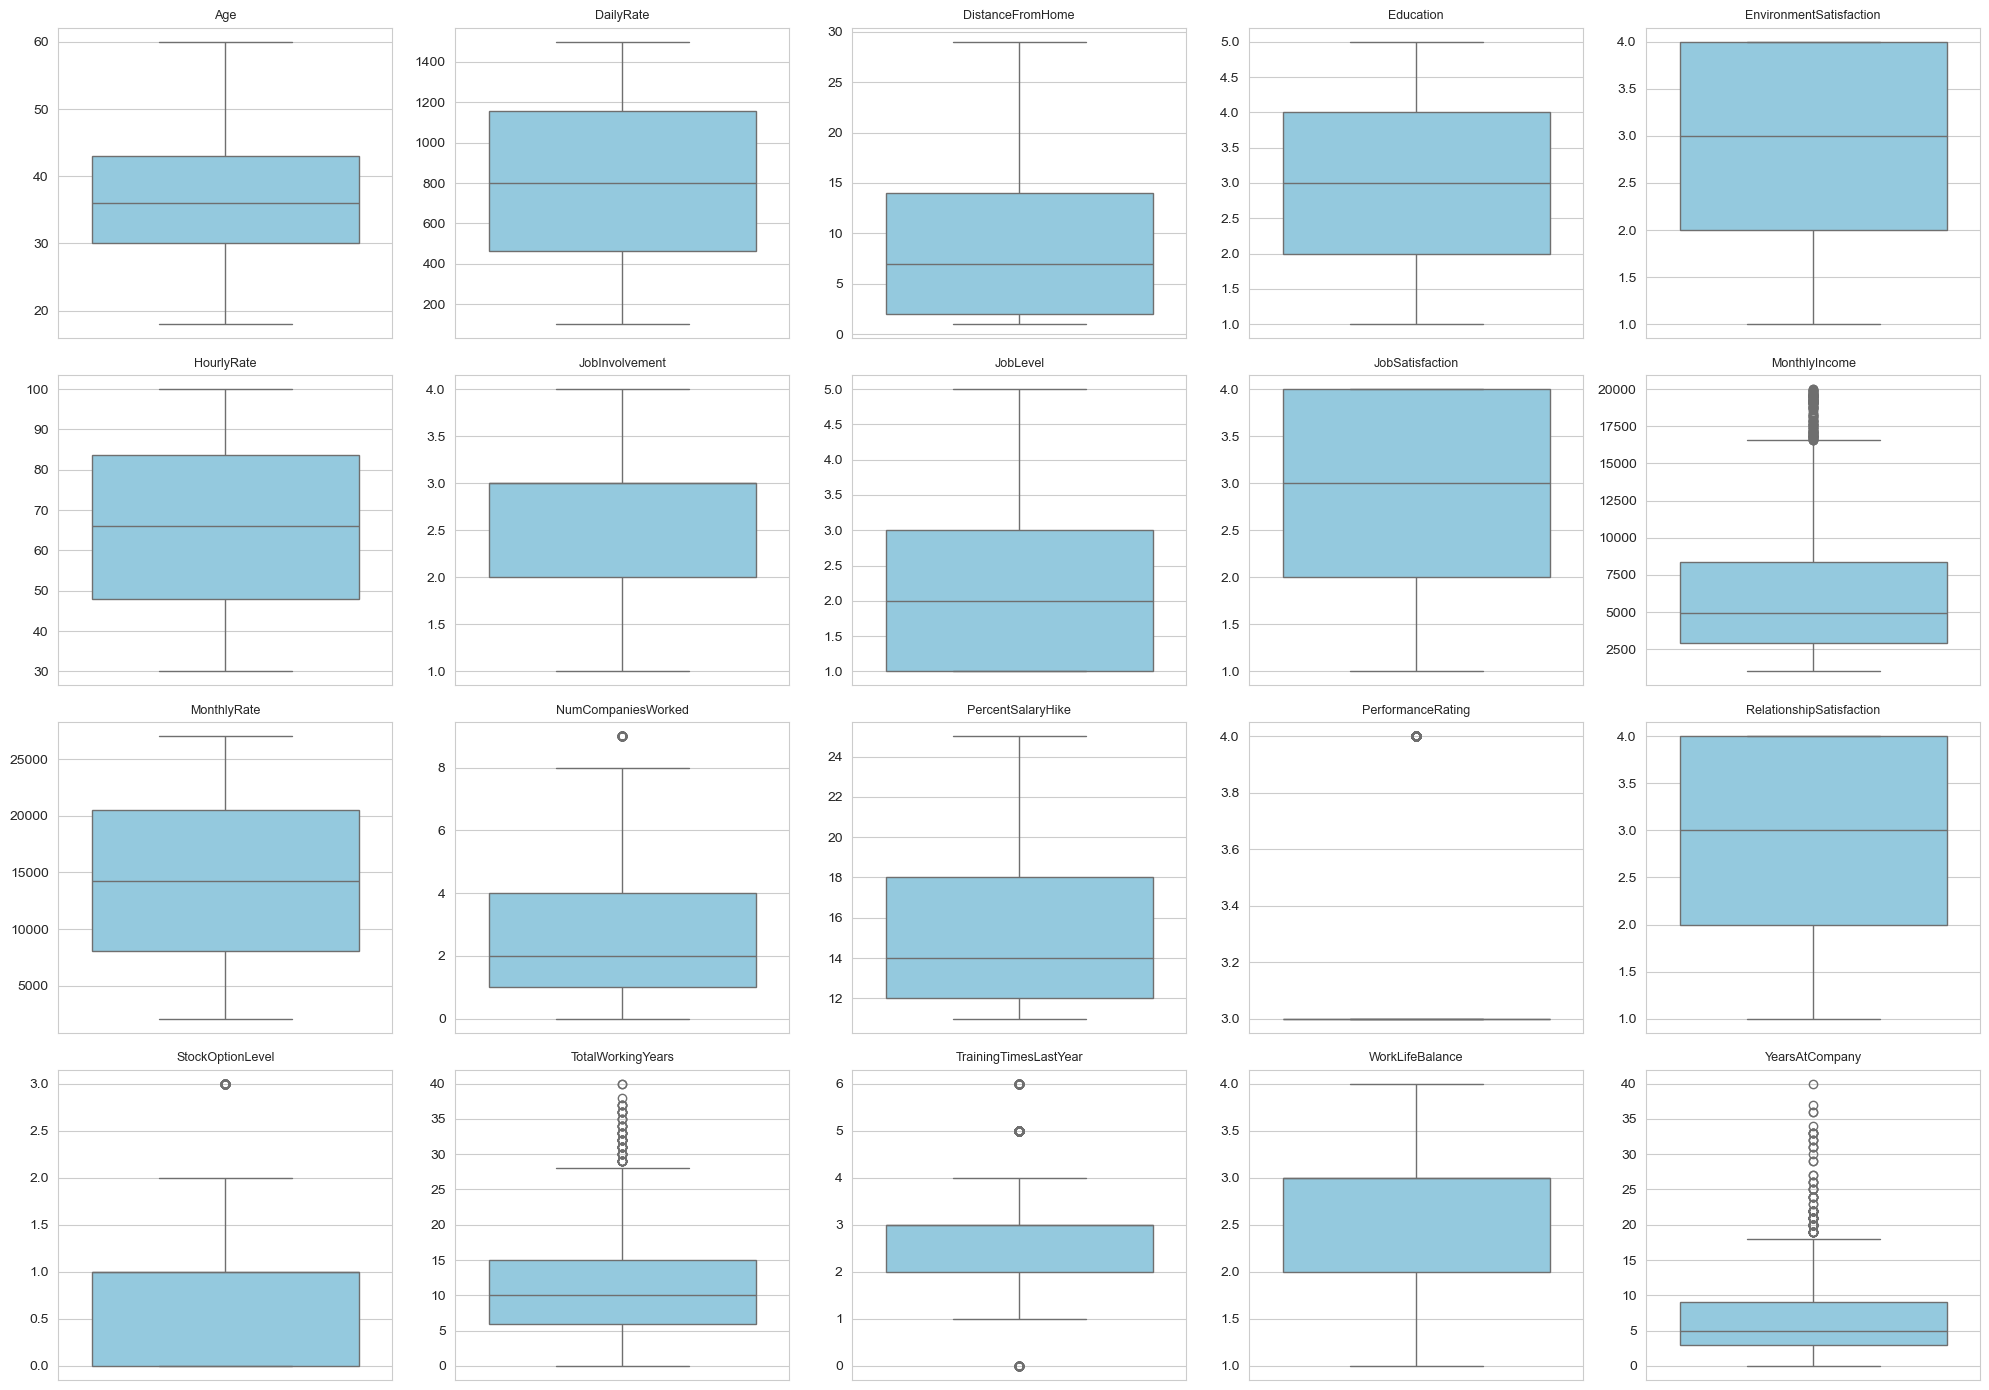

In [49]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:20]):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("")
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("charts/01_outlier_boxplots.png", dpi=150)
plt.show()


In [50]:
# Quantify potential outliers using the IQR method

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": outlier_count,
        "Outlier %": round(outlier_count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary[outlier_summary["Outlier Count"] > 0]

,Feature,Outlier Count,Outlier %
9,MonthlyIncome,114,7.76
11,NumCompaniesWorked,52,3.54
13,PerformanceRating,226,15.37
15,StockOptionLevel,85,5.78
16,TotalWorkingYears,63,4.29
17,TrainingTimesLastYear,238,16.19
19,YearsAtCompany,104,7.07
20,YearsInCurrentRole,21,1.43
21,YearsSinceLastPromotion,107,7.28
22,YearsWithCurrManager,14,0.95


**Outlier Handling Decision**

Potential outliers were identified using boxplots and the IQR method.

The identified observations were retained because extreme values in variables
such as MonthlyIncome, TotalWorkingYears and YearsAtCompany can represent
legitimate employee characteristics, such as senior or highly experienced
employees, rather than data-entry errors.

Therefore, no observations were removed or capped solely because they were
identified as statistical outliers. This preserves the original employee
population and avoids removing potentially meaningful information.

The outliers were therefore handled through detection, investigation and
documented justification rather than automatic removal.

### 4.6 Encoding

In [51]:
# Convert simple Yes/No columns into 1/0
yes_no_columns = ["Attrition", "OverTime"]
for col in yes_no_columns:
    if col in df.columns:
        df[col] = df[col].map({"Yes": 1, "No": 0})

# One-hot encode the remaining multi-category columns
categorical_columns = df.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns encoded: {categorical_columns}")

df_clean = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
print(f"Final cleaned shape: {df_clean.shape}")

df_clean.to_csv("Employee-Attrition-Clean.csv", index=False)
print("Saved Employee-Attrition-Clean.csv")


Categorical columns encoded: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']
Final cleaned shape: (1470, 45)
Saved Employee-Attrition-Clean.csv


## 5. Exploratory Data Analysis

For readability, charts use the pre-encoding version of the data (plain text
labels like "Yes"/"No" and department names), while the correlation heatmap
uses the fully encoded numeric version.

In [52]:
df_eda = df.copy()
df_eda["Attrition"] = df_eda["Attrition"].map({1: "Yes", 0: "No"})

### 5.1 Attrition distribution

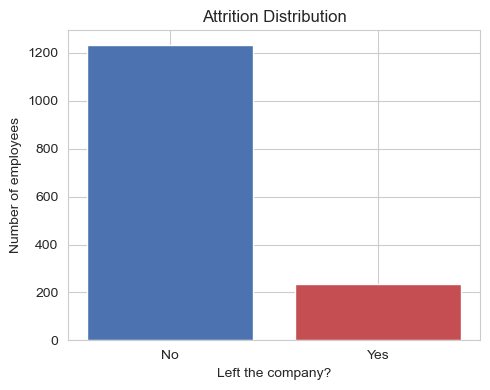

Attrition rate: 16.1%


In [53]:
plt.figure(figsize=(5, 4))
order = ["No", "Yes"]
colors_map = {"No": "#4C72B0", "Yes": "#C44E52"}
counts = df_eda["Attrition"].value_counts().reindex(order)

plt.bar(order, counts.values, color=[colors_map[o] for o in order])
plt.title("Attrition Distribution")
plt.xlabel("Left the company?")
plt.ylabel("Number of employees")
plt.tight_layout()
plt.savefig("charts/02_attrition_distribution.png", dpi=150)
plt.show()
rate = df_eda["Attrition"].value_counts(normalize=True)["Yes"]
print(f"Attrition rate: {rate:.1%}")


**Reading this chart:** the dataset is imbalanced — far fewer employees
left than stayed. This is why accuracy alone would be a misleading metric
later; we'll need F1 / PR-AUC for the supervised models.

### 5.2 Numerical distributions

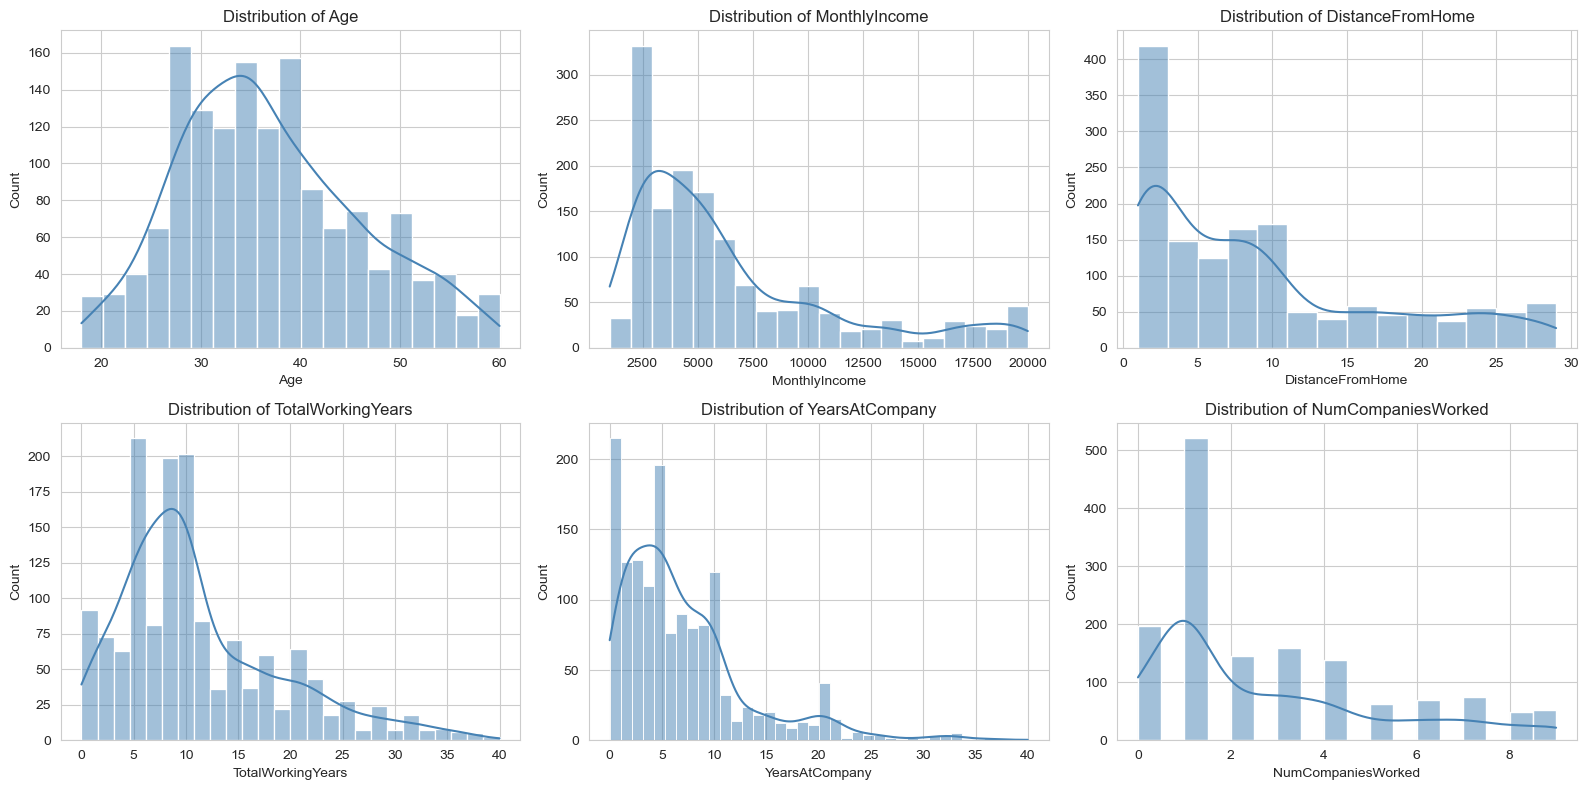

In [54]:
key_numeric = ["Age", "MonthlyIncome", "DistanceFromHome", "TotalWorkingYears",
                "YearsAtCompany", "NumCompaniesWorked"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(key_numeric):
    sns.histplot(df_eda[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("charts/03_numerical_distributions.png", dpi=150)
plt.show()


### 5.3 Categorical vs Attrition

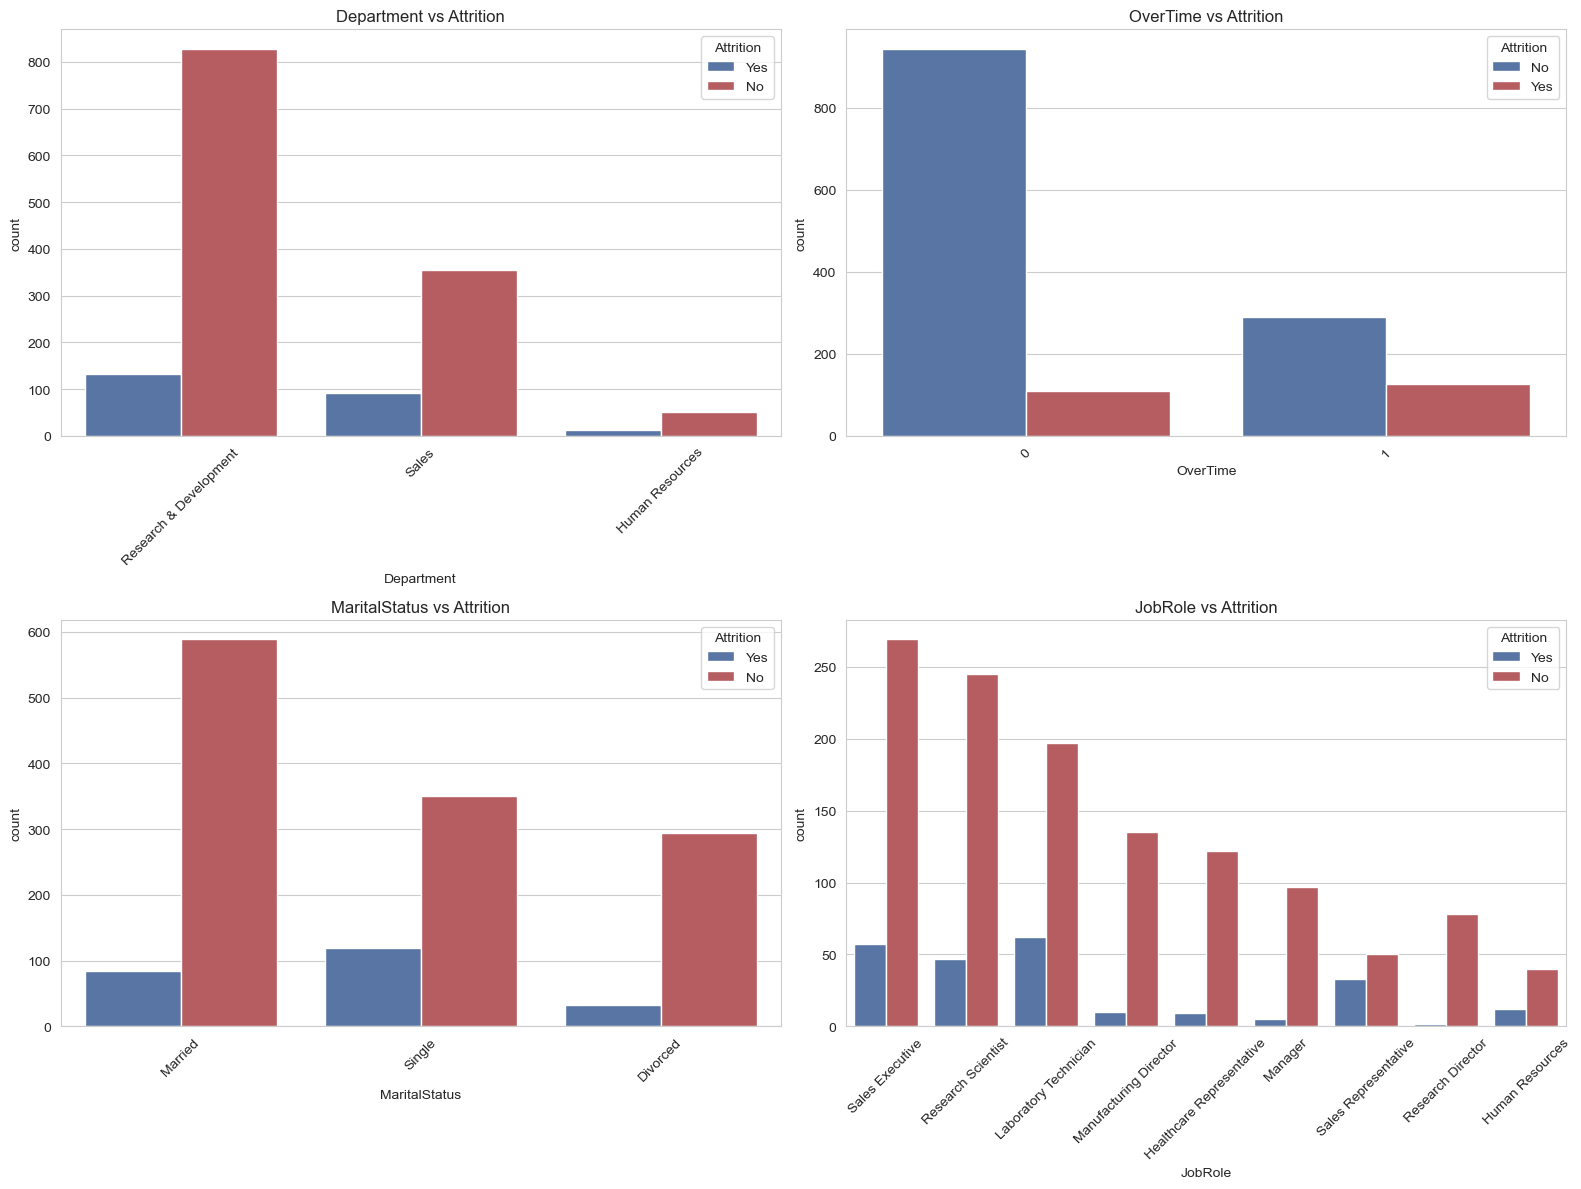

In [55]:
key_categorical = ["Department", "OverTime", "MaritalStatus", "JobRole"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(key_categorical):
    order = df_eda[col].value_counts().index
    sns.countplot(data=df_eda, x=col, hue="Attrition", ax=axes[i], order=order,
                  palette=["#4C72B0", "#C44E52"])
    axes[i].set_title(f"{col} vs Attrition")
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/04_categorical_vs_attrition.png", dpi=150)
plt.show()


**Reading this chart:** watch for categories where the red ("Yes") share
looks noticeably bigger — e.g. employees who work overtime tend to show a
higher share of attrition than those who don't.

### 5.4 Numerical vs Attrition

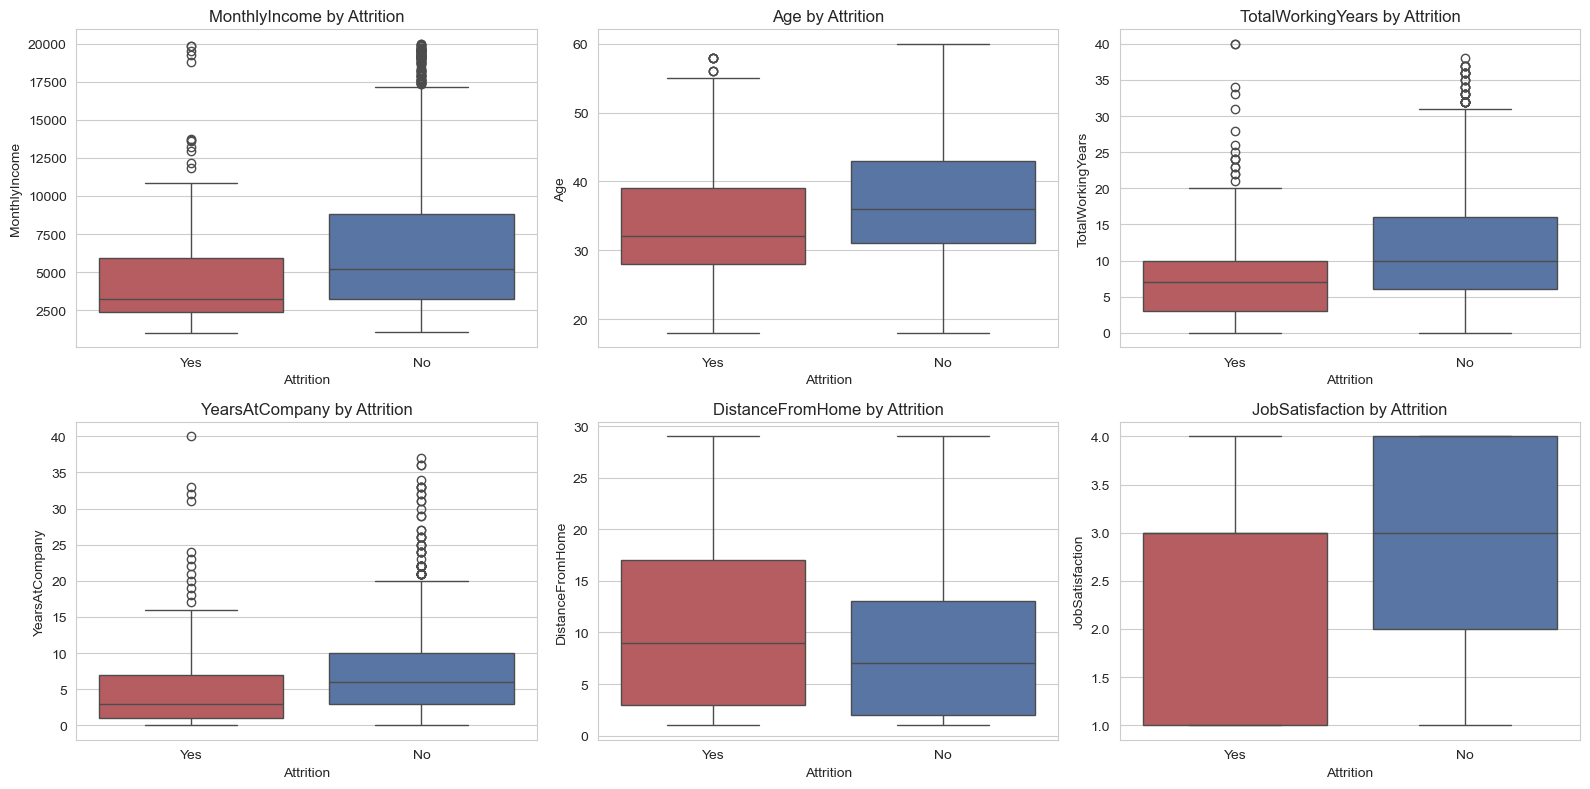

In [56]:
key_numeric_2 = ["MonthlyIncome", "Age", "TotalWorkingYears",
                  "YearsAtCompany", "DistanceFromHome", "JobSatisfaction"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(key_numeric_2):
    sns.boxplot(data=df_eda, x="Attrition", y=col, hue="Attrition", ax=axes[i],
                palette={"No": "#4C72B0", "Yes": "#C44E52"}, legend=False)
    axes[i].set_title(f"{col} by Attrition")
plt.tight_layout()
plt.savefig("charts/05_numerical_vs_attrition.png", dpi=150)
plt.show()


### 5.5 Correlation analysis

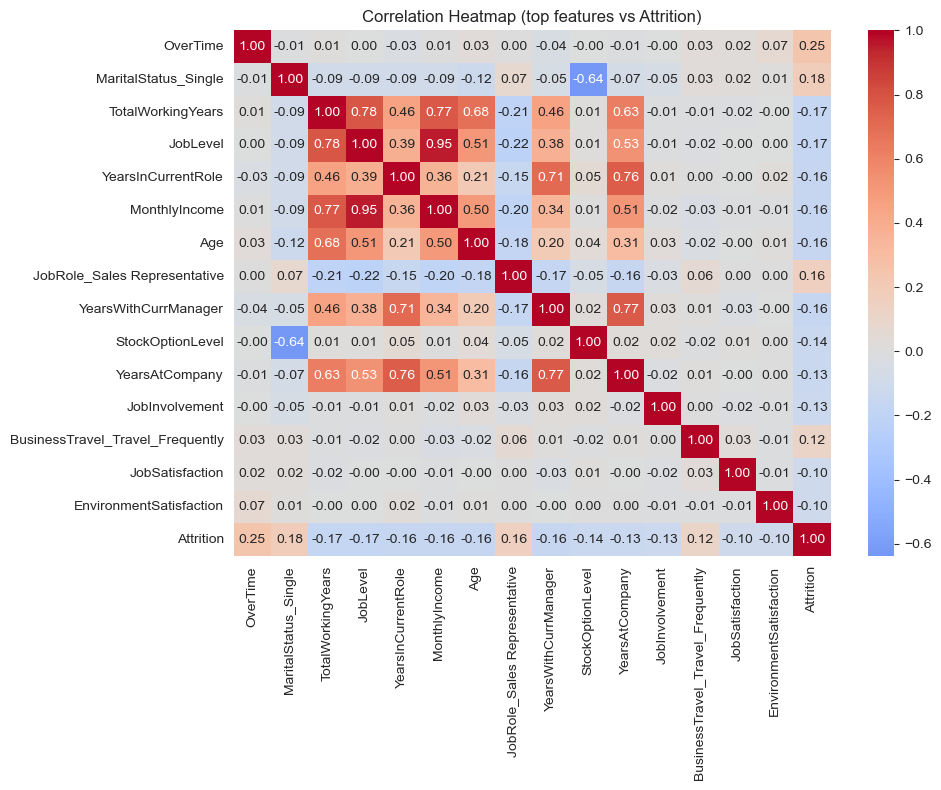

Features most correlated with Attrition:


Attrition                       1.000000
OverTime                        0.246118
MaritalStatus_Single            0.175419
TotalWorkingYears              -0.171063
JobLevel                       -0.169105
YearsInCurrentRole             -0.160545
MonthlyIncome                  -0.159840
Age                            -0.159205
JobRole_Sales Representative    0.157234
YearsWithCurrManager           -0.156199
Name: Attrition, dtype: float64

In [57]:
plt.figure(figsize=(10, 8))
top_corr = df_clean.corr(numeric_only=True)["Attrition"].sort_values(key=abs, ascending=False)
top_features = top_corr.index[1:16]  # skip Attrition itself, take top 15
corr_matrix = df_clean[top_features.tolist() + ["Attrition"]].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (top features vs Attrition)")
plt.tight_layout()
plt.savefig("charts/06_correlation_heatmap.png", dpi=150)
plt.show()

print("Features most correlated with Attrition:")
top_corr.head(10)


**Key takeaway:** no single factor strongly drives attrition on its own
(all correlations are below 0.3). `OverTime`, being `Single`, and having fewer
`TotalWorkingYears` / lower `JobLevel` / lower `MonthlyIncome` / younger `Age`
show the clearest — but still modest — links. This matches what we'll likely
see later in clustering: attrition risk is a mix of many small signals rather
than one dominant cause.

## 6. Unsupervised Learning

The goal of the unsupervised analysis is to identify employee personas based
on characteristics related to engagement, satisfaction, workload and tenure.

Attrition is excluded from the clustering features because it is the outcome
we want to examine after creating the employee groups. This prevents the
clustering process from using the target variable to define the personas.

### 6.1 Feature Selection

The following variables were selected to represent four relevant aspects of
the employee experience:

- Engagement: JobInvolvement
- Satisfaction: JobSatisfaction, EnvironmentSatisfaction,
  RelationshipSatisfaction and WorkLifeBalance
- Workload: OverTime
- Tenure: TotalWorkingYears, YearsAtCompany, YearsInCurrentRole,
  YearsSinceLastPromotion and YearsWithCurrManager

These features are used to create employee personas without directly using
Attrition.

In [58]:
# Features selected for employee persona clustering

cluster_features = [
    "JobInvolvement",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
    "OverTime",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

cluster_df = df_eda[cluster_features].copy()

# Convert OverTime to numerical form for clustering
cluster_df = df_eda[cluster_features].copy()

print("Clustering data shape:", cluster_df.shape)
cluster_df.head()

Clustering data shape: (1470, 11)


,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,OverTime,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3,4,2,1,1,1,8,6,4,0,5
1,2,2,3,4,3,0,10,10,7,1,7
2,2,3,4,2,3,1,7,0,0,0,0
3,3,3,4,3,3,1,8,8,7,3,0
4,3,2,1,4,3,0,6,2,2,2,2


### 6.2 Feature Scaling

The selected variables have different numerical ranges. For example,
tenure variables are measured in years, satisfaction variables use rating
scales, and OverTime is binary.

StandardScaler is therefore used so that each feature contributes on a
comparable scale. This is particularly important for PCA and K-Means because
both rely on the geometry of the feature space.

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_cluster_scaled = scaler.fit_transform(cluster_df)

print("Scaled data shape:", X_cluster_scaled.shape)

Scaled data shape: (1470, 11)


## 6.3 Principal Component Analysis (PCA)

PCA is applied to the standardized clustering features to reduce
dimensionality and identify the main dimensions of variation among
employees.

The explained variance ratio is examined to determine how much of the
total variation is captured by each principal component. The cumulative
explained variance is then used to justify the number of components
retained.

In [60]:
from sklearn.decomposition import PCA

# Fit PCA using all available components
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_cluster_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

pca_summary = pd.DataFrame({
    "Component": range(1, len(explained_variance) + 1),
    "Explained Variance": explained_variance,
    "Cumulative Variance": cumulative_variance
})

pca_summary.round(4)

,Component,Explained Variance,Cumulative Variance
0,1,0.3073,0.3073
1,2,0.0994,0.4067
2,3,0.0952,0.5019
3,4,0.0939,0.5958
4,5,0.0892,0.6850
5,6,0.0874,0.7724
6,7,0.0815,0.8539
7,8,0.0564,0.9104
8,9,0.0481,0.9585
9,10,0.0256,0.9841


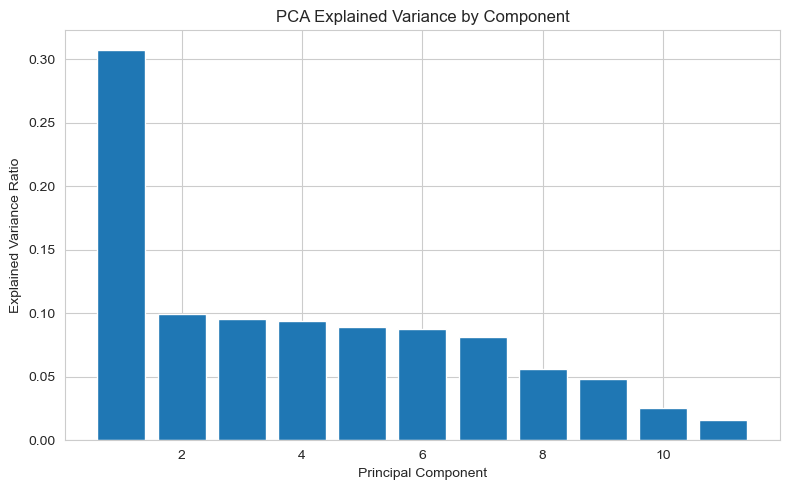

In [61]:
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, len(explained_variance) + 1),
    explained_variance
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance by Component")

plt.tight_layout()
plt.show()

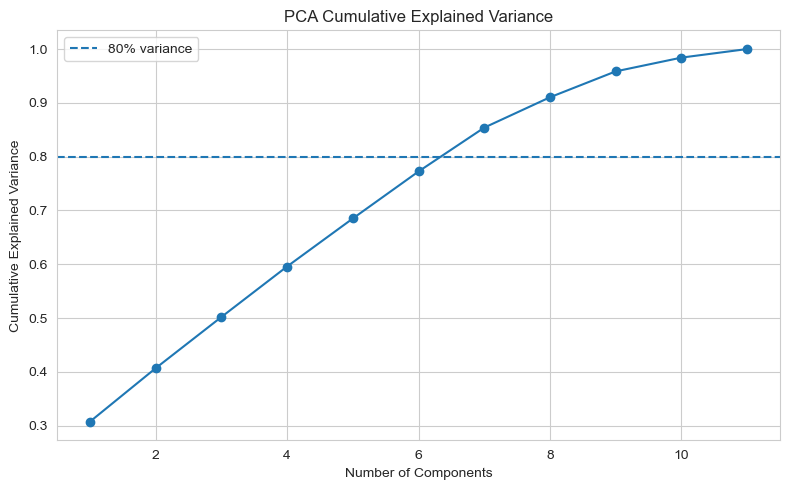

In [62]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    0.80,
    linestyle="--",
    label="80% variance"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.legend()
plt.tight_layout()
plt.show()

In [63]:
n_components_80 = np.argmax(
    cumulative_variance >= 0.80
) + 1

print(
    f"Components needed for at least 80% variance: "
    f"{n_components_80}"
)

print(
    f"Variance explained: "
    f"{cumulative_variance[n_components_80 - 1]:.2%}"
)

Components needed for at least 80% variance: 7
Variance explained: 85.39%


In [64]:
# PCA loadings for the first two principal components

pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_cluster_scaled)

loadings = pd.DataFrame(
    pca_2.components_.T,
    columns=["PC1", "PC2"],
    index=cluster_features
)

loadings.round(3)

,PC1,PC2
JobInvolvement,-0.003,0.044
JobSatisfaction,-0.013,0.060
EnvironmentSatisfaction,0.005,0.560
RelationshipSatisfaction,0.010,0.449
WorkLifeBalance,0.015,0.033
OverTime,-0.016,0.688
TotalWorkingYears,0.382,0.047
YearsAtCompany,0.505,0.007
YearsInCurrentRole,0.468,-0.021
YearsSinceLastPromotion,0.404,0.033


In [65]:
print("Strongest contributors to PC1:")
print(
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .head(5)
)

print("\nStrongest contributors to PC2:")
print(
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
    .head(5)
)

Strongest contributors to PC1:
YearsAtCompany             0.505290
YearsInCurrentRole         0.467851
YearsWithCurrManager       0.464415
YearsSinceLastPromotion    0.403979
TotalWorkingYears          0.382238
Name: PC1, dtype: float64

Strongest contributors to PC2:
OverTime                    0.687917
EnvironmentSatisfaction     0.559676
RelationshipSatisfaction    0.448637
JobSatisfaction             0.060341
TotalWorkingYears           0.046648
Name: PC2, dtype: float64


### PCA Component Interpretation

The PCA loadings show that the first two principal components capture
different aspects of employee characteristics.

**PC1 — Tenure and Organizational Experience**

PC1 is dominated by YearsAtCompany (0.505), YearsInCurrentRole (0.468),
YearsWithCurrManager (0.464), YearsSinceLastPromotion (0.404), and
TotalWorkingYears (0.382). Therefore, PC1 can be interpreted as a
tenure and organizational experience dimension. Higher PC1 values are
associated mainly with employees who have longer organizational and
professional experience.

**PC2 — Workload and Workplace Satisfaction**

PC2 is dominated by OverTime (0.688), EnvironmentSatisfaction (0.560),
and RelationshipSatisfaction (0.449). Therefore, PC2 can be interpreted
primarily as a workload and workplace satisfaction dimension, with
OverTime being the strongest contributor.

The signs of PCA loadings indicate the direction of the relationship, but
the overall sign of a principal component is arbitrary. Therefore, the
interpretation focuses mainly on the magnitude and relative contribution
of the loadings.

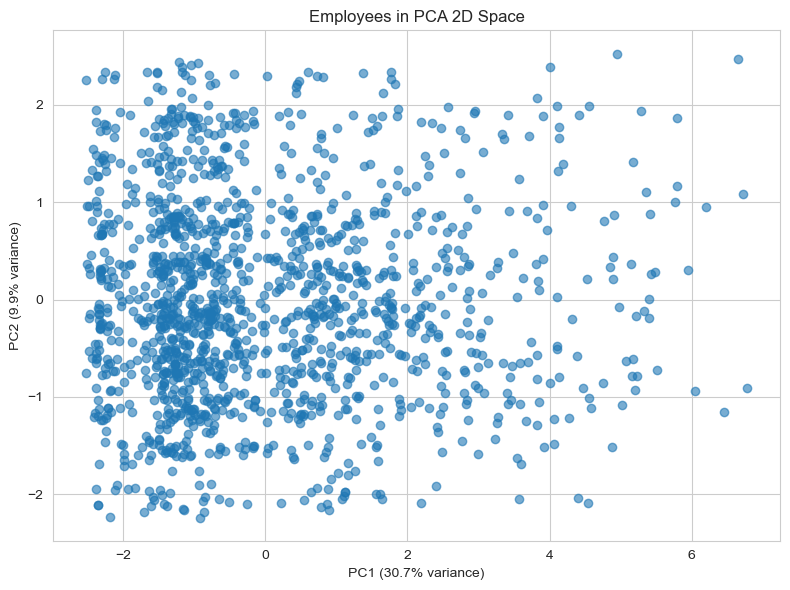

In [66]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    alpha=0.6
)

plt.xlabel(
    f"PC1 ({pca_2.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca_2.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.title("Employees in PCA 2D Space")

plt.tight_layout()
plt.show()

## 6.4 K-Means Clustering

K-Means clustering is used to group employees into personas based on their
engagement, satisfaction, workload and tenure characteristics.

The clustering is performed on the standardized features so that variables
with larger numerical ranges do not dominate the distance calculations.

Different values of K are evaluated using the elbow method and silhouette
score before selecting the final number of clusters.

In [80]:
#Testing different values of K
import os
import warnings
warnings.filterwarnings("ignore")
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 9)

inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster_scaled, labels)
    )

print("K values tested:", list(K_range))

K values tested: [2, 3, 4, 5, 6, 7, 8]


In [81]:
cluster_evaluation = pd.DataFrame({
    "K": list(K_range),
    "WCSS / Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

cluster_evaluation.round(4)

,K,WCSS / Inertia,Silhouette Score
0,2,12683.3957,0.2176
1,3,11613.1774,0.1444
2,4,10792.2576,0.1404
3,5,10246.4619,0.1117
4,6,9844.5226,0.1133
5,7,9560.2428,0.1134
6,8,9202.2145,0.1059


### Elbow Method

The elbow method evaluates the within-cluster sum of squares (WCSS), also
reported as K-Means inertia. As the number of clusters increases, WCSS
decreases because observations are assigned to more groups.

The preferred K is around the point where adding additional clusters gives
substantially smaller improvements.

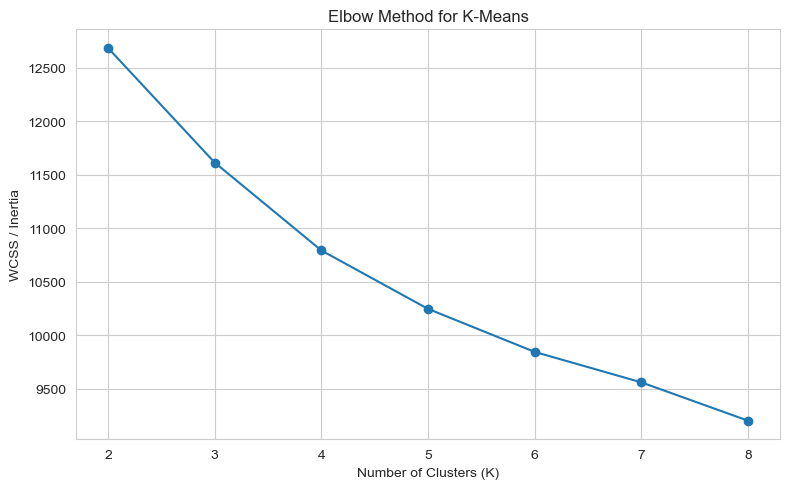

In [82]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(K_range),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method for K-Means")

plt.xticks(list(K_range))

plt.tight_layout()
plt.show()

### Silhouette Score

The silhouette score measures how well observations fit within their own
cluster compared with other clusters. Higher values indicate better-defined
and more separated clusters.

The silhouette score is therefore used together with the elbow method rather
than relying on WCSS alone.

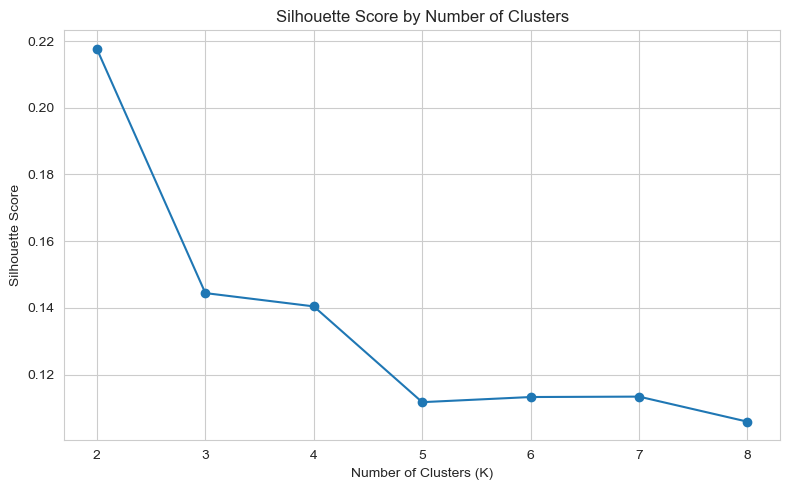

In [83]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(K_range),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.xticks(list(K_range))

plt.tight_layout()
plt.show()

In [84]:
#Find the Best Silhouette K
best_k_silhouette = list(K_range)[
    np.argmax(silhouette_scores)
]

best_silhouette = max(silhouette_scores)

print(
    f"Best K according to silhouette score: "
    f"{best_k_silhouette}"
)

print(
    f"Best silhouette score: "
    f"{best_silhouette:.4f}"
)

Best K according to silhouette score: 2
Best silhouette score: 0.2176


In [85]:
for k in [2, 3]:
    
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    print(f"\nK = {k}")
    print("Cluster sizes:")
    print(pd.Series(labels).value_counts().sort_index())
    
    print(
        "Silhouette score:",
        round(silhouette_score(X_cluster_scaled, labels), 4)
    )


K = 2
Cluster sizes:
0    957
1    513
Name: count, dtype: int64
Silhouette score: 0.2176

K = 3
Cluster sizes:
0    734
1    414
2    322
Name: count, dtype: int64
Silhouette score: 0.1444


In [86]:
cluster_evaluation = pd.DataFrame({
    "K": list(K_range),
    "WCSS / Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

cluster_evaluation.round(4)

,K,WCSS / Inertia,Silhouette Score
0,2,12683.3957,0.2176
1,3,11613.1774,0.1444
2,4,10792.2576,0.1404
3,5,10246.4619,0.1117
4,6,9844.5226,0.1133
5,7,9560.2428,0.1134
6,8,9202.2145,0.1059


### Selecting the Number of Clusters

The number of clusters was evaluated using both WCSS (inertia) and the
silhouette score.

The silhouette score was highest for K=2, with a score of 0.2176. The score
decreased when additional clusters were introduced. Therefore, K=2 provides
the strongest separation among the tested solutions.

Although the silhouette score is relatively low, indicating that the
clusters are not strongly separated, K=2 is selected because it provides
the best-supported solution according to the clustering evaluation.

The final K-Means model therefore uses two employee clusters.

In [89]:
# Final K-Means model

final_k = 2

kmeans_final = KMeans(
    n_clusters=final_k,
    init="k-means++",
    n_init=10,
    random_state=42
)

cluster_labels = kmeans_final.fit_predict(X_cluster_scaled)

df_clusters = df_eda.copy()

df_clusters["Cluster"] = cluster_labels

print("Final number of clusters:", final_k)
print("\nCluster sizes:")
print(
    df_clusters["Cluster"]
    .value_counts()
    .sort_index()
)

Final number of clusters: 2

Cluster sizes:
Cluster
0    957
1    513
Name: count, dtype: int64


In [91]:
cluster_profile = (
    df_clusters
    .groupby("Cluster")[cluster_features]
    .mean()
    .round(2)
)

cluster_profile

,JobInvolvement,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,WorkLifeBalance,OverTime,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Cluster,,,,,,,,,,,
0,2.72,2.73,2.71,2.72,2.75,0.30,8.56,3.73,2.15,0.75,2.07
1,2.75,2.73,2.74,2.70,2.78,0.25,16.35,13.13,8.10,4.88,7.96


In [92]:
cluster_sizes = (
    df_clusters["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_summary = pd.DataFrame({
    "Employees": cluster_sizes,
    "Percentage": (
        cluster_sizes / len(df_clusters) * 100
    ).round(2)
})

cluster_summary

,Employees,Percentage
Cluster,,
0,957,65.1
1,513,34.9


In [93]:
cluster_attrition = pd.crosstab(
    df_clusters["Cluster"],
    df_clusters["Attrition"],
    normalize="index"
) * 100

cluster_attrition.round(2)

Attrition,No,Yes
Cluster,,
0,81.19,18.81
1,88.89,11.11


### Cluster Profile Interpretation

The K-Means results identify two distinct employee personas. The main
difference between the clusters is tenure and professional experience,
rather than satisfaction.

**Cluster 0 — Early-Tenure Employees**

Cluster 0 contains 957 employees. This group has substantially lower
organizational and professional tenure, with average TotalWorkingYears of
8.56 years and YearsAtCompany of 3.73 years. Employees in this group also
show slightly higher overtime participation (0.30).

The observed attrition rate for this cluster is 18.81%.

**Cluster 1 — Experienced Long-Tenure Employees**

Cluster 1 contains 513 employees. This group is characterized by much
greater professional and organizational experience, with average
TotalWorkingYears of 16.35 years and YearsAtCompany of 13.13 years.
Employees also have substantially longer tenure in their current role and
with their current manager.

The observed attrition rate for this cluster is 11.11%.

Overall, the clustering solution suggests that tenure and experience are
the strongest characteristics distinguishing the two employee personas,
while the satisfaction and engagement measures are relatively similar
between the clusters.

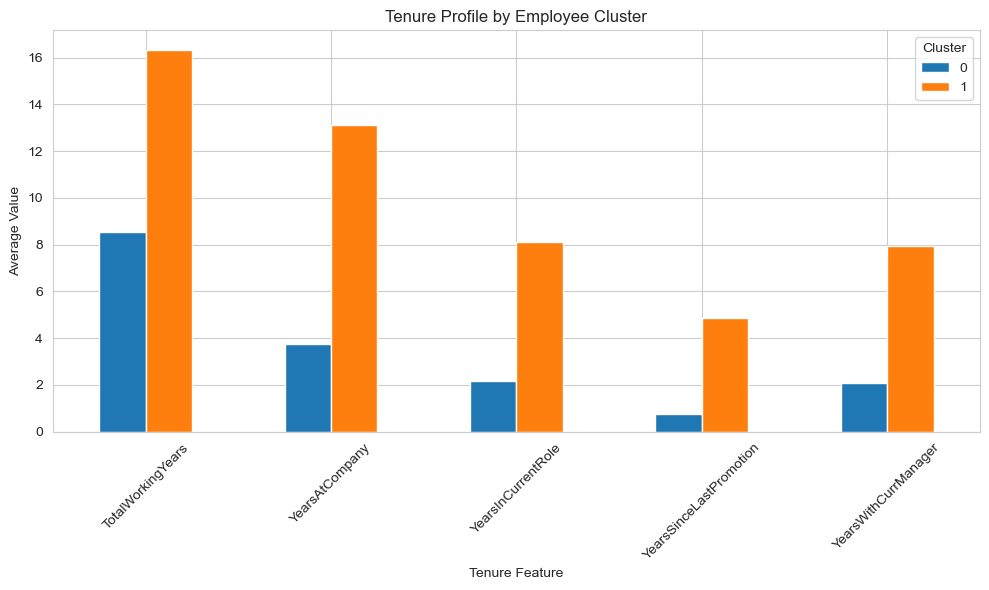

In [97]:
# Compare key tenure characteristics across clusters

profile_plot = cluster_profile[
    [
        "TotalWorkingYears",
        "YearsAtCompany",
        "YearsInCurrentRole",
        "YearsSinceLastPromotion",
        "YearsWithCurrManager"
    ]
]

profile_plot.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Tenure Profile by Employee Cluster")
plt.xlabel("Tenure Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

### Cluster and Attrition Relationship

The observed attrition rate is higher in Cluster 0 (18.81%) than in
Cluster 1 (11.11%). This indicates that the early-tenure employee persona
has a higher observed attrition level in this dataset.

However, clustering is descriptive and does not establish that shorter
tenure or overtime causes attrition. The relationship should therefore be
examined further using the supervised learning models.

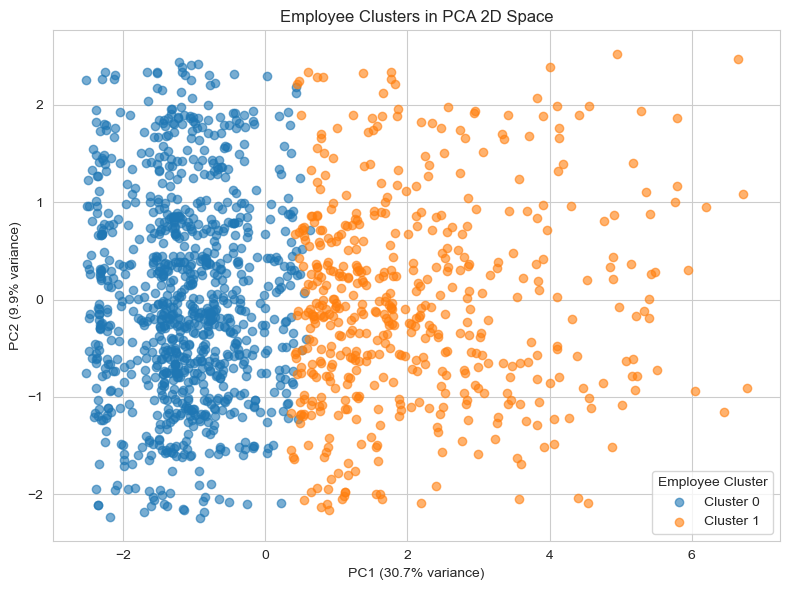

In [101]:
# Visualize the final K-Means clusters using the first two PCA components

plt.figure(figsize=(8, 6))

for cluster in sorted(df_clusters["Cluster"].unique()):
    
    subset = X_pca_2[
        df_clusters["Cluster"].values == cluster
    ]
    
    plt.scatter(
        subset[:, 0],
        subset[:, 1],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel(
    f"PC1 ({pca_2.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca_2.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.title("Employee Clusters in PCA 2D Space")
plt.legend(title="Employee Cluster")

plt.tight_layout()
plt.show()

In [103]:
cluster_sizes = (
    df_clusters["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_summary = pd.DataFrame({
    "Employees": cluster_sizes,
    "Percentage": (
        cluster_sizes / len(df_clusters) * 100
    ).round(2)
})

cluster_summary

,Employees,Percentage
Cluster,,
0,957,65.1
1,513,34.9


In [100]:
cluster_final_summary = pd.DataFrame({
    "Employees": cluster_sizes,
    "Percentage": (
        cluster_sizes / len(df_clusters) * 100
    ).round(2),
    "Attrition Rate": (
        df_clusters
        .groupby("Cluster")["Attrition"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .round(2)
    )
})

cluster_final_summary

,Employees,Percentage,Attrition Rate
Cluster,,,
0,957,65.1,18.81
1,513,34.9,11.11


## Employee Persona Interpretation

### Persona 1 — Early-Tenure Employees

Cluster 0 contains 957 employees (65.10% of the dataset). This group is
characterized by relatively lower professional and organizational tenure.
Average TotalWorkingYears is 8.56 years, while YearsAtCompany is 3.73
years.

The group also has slightly higher average OverTime participation (0.30)
compared with Cluster 1 (0.25).

The observed attrition rate for this persona is 18.81%, which is higher
than the attrition rate of the experienced employee persona.

### Persona 2 — Experienced Long-Tenure Employees

Cluster 1 contains 513 employees (34.90% of the dataset). This group is
characterized by substantially greater professional and organizational
experience. Average TotalWorkingYears is 16.35 years and YearsAtCompany is
13.13 years.

Employees in this cluster also have substantially longer tenure in their
current role, more years since their last promotion, and more years with
their current manager.

The observed attrition rate for this persona is 11.11%.

### Overall Interpretation

The main distinction between the two employee personas is tenure and
professional experience. Satisfaction and engagement variables are relatively
similar across the clusters, while tenure-related variables show much larger
differences.

The early-tenure persona has a higher observed attrition rate (18.81%)
compared with the experienced long-tenure persona (11.11%). This suggests
that the early-tenure group may warrant particular attention when examining
employee retention.

However, these clustering results are descriptive and do not establish that
shorter tenure or overtime causes attrition. The relationship should be
investigated further using the supervised learning models.

## Unsupervised Learning Conclusion

The unsupervised analysis followed a structured process of feature selection,
standardization, PCA and K-Means clustering.

Eleven features representing employee engagement, satisfaction, workload and
tenure were selected for clustering. The features were standardized using
StandardScaler to ensure that variables with different numerical scales did
not disproportionately influence PCA or K-Means.

PCA showed that the first seven components explain 85.39% of the total
variance. The first two components explain 40.67% and were therefore used for
two-dimensional visualization and component interpretation.

K-Means solutions from K=2 to K=8 were evaluated using WCSS/inertia and
silhouette scores. K=2 produced the highest silhouette score of 0.2176 and
was selected as the final clustering solution. The relatively low silhouette
score indicates that the two groups are not strongly separated, so the
personas should be interpreted as broad employee segments rather than
completely distinct groups.

The final solution identified two employee personas: an early-tenure group
and an experienced long-tenure group. The early-tenure group had an observed
attrition rate of 18.81%, compared with 11.11% for the experienced
long-tenure group.

These personas provide a useful descriptive view of the employee population
and identify differences in observed attrition patterns. The findings will
be complemented by supervised learning to determine which employee
characteristics are most useful for predicting individual attrition risk.